# Liver Disease Prediction 
Dataset: Indian Liver Patient Dataset (ILPD)  


## 1 · Imports & Data Load

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
import joblib, json

df = pd.read_csv("../data/indian_liver_patient.csv")
df['target'] = (df['Dataset'] == 1).astype(int)
print(df.shape)
df.head()

(583, 12)


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset,target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1,1


In [2]:
df.info()
print(df.isnull().sum())
print('Target balance:', df['target'].value_counts().to_dict())

<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
 11  target                      583 non-null    int64  
dtypes: float64(5), int64(6), str(1)
memory usage: 54.8 KB
Age                           0
Gender           

## 2 · EDA

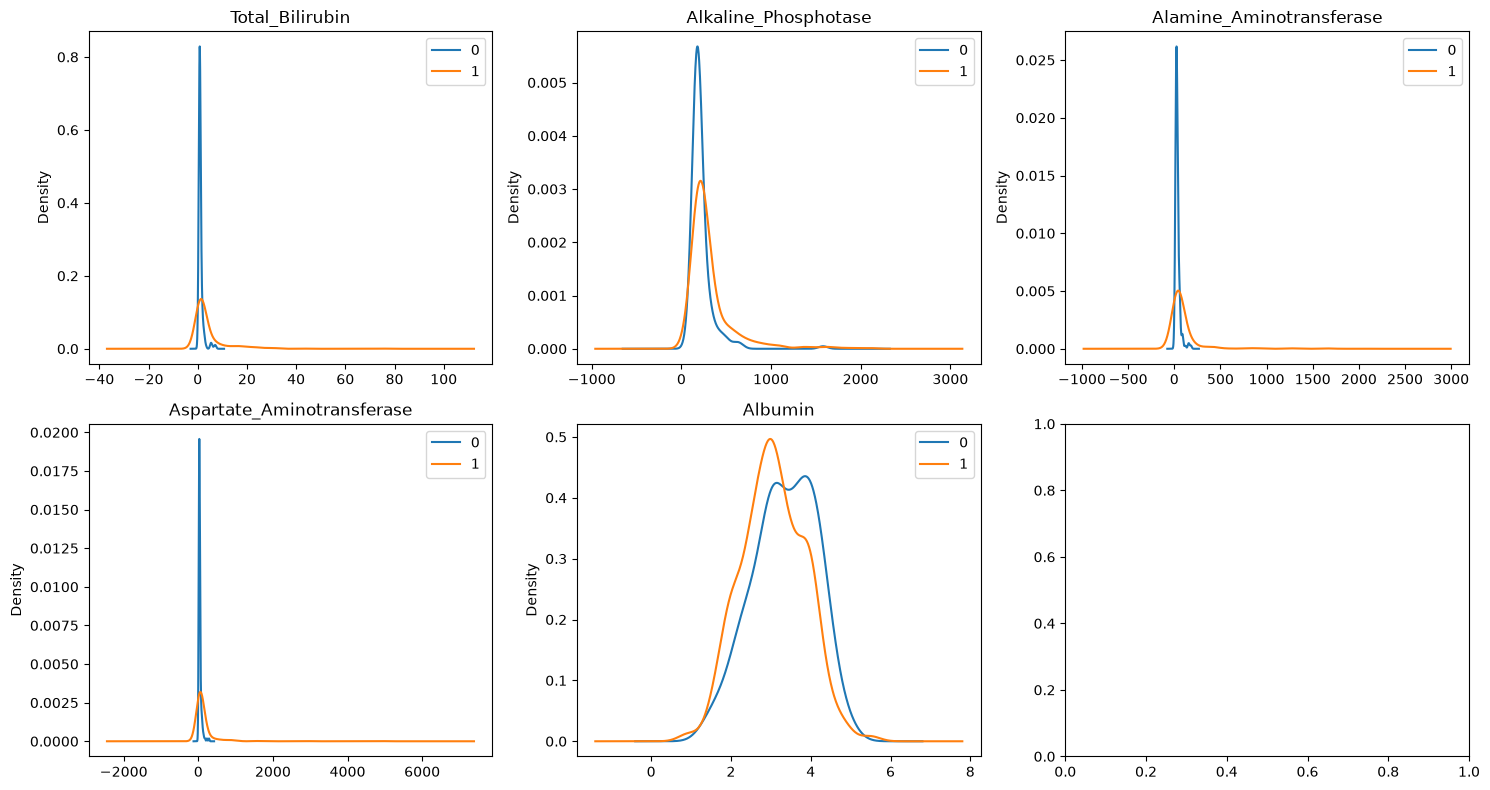

In [3]:
fig, axes = plt.subplots(2,3, figsize=(15,8))
for i, col in enumerate(['Total_Bilirubin','Alkaline_Phosphotase',
                          'Alamine_Aminotransferase','Aspartate_Aminotransferase','Albumin']):
    ax = axes[i//3][i%3]
    df.groupby('target')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)
plt.tight_layout(); plt.show()

## 3 · Feature Engineering & Field Mapping


In [4]:
df['alcohol_consumption'] = 0

FEATURES = ['Age','Total_Bilirubin','Alkaline_Phosphotase',
            'Alamine_Aminotransferase','Aspartate_Aminotransferase',
            'Albumin','alcohol_consumption']
X = df[FEATURES].rename(columns={'Age':'age','Total_Bilirubin':'bilirubin',
    'Alkaline_Phosphotase':'alkphos','Alamine_Aminotransferase':'sgpt',
    'Aspartate_Aminotransferase':'sgot','Albumin':'albumin'})
y = df['target']

## 4–5 · Preprocessing & Split

In [5]:
def make_pipe(clf):
    return Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler',  StandardScaler()), ('clf', clf)])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (466, 7), Test: (117, 7)


## 6 · Model Training & Comparison

In [7]:
candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost':            XGBClassifier(n_estimators=200, random_state=42,
                                        eval_metric='logloss', verbosity=0),
}
results = {}; pipes = {}
for name, clf in candidates.items():
    p = make_pipe(clf); p.fit(X_train, y_train)
    yp  = p.predict(X_test)
    ypr = p.predict_proba(X_test)[:,1]
    results[name] = {'accuracy':  round(accuracy_score(y_test,yp),4),
                     'precision': round(precision_score(y_test,yp),4),
                     'recall':    round(recall_score(y_test,yp),4),
                     'f1':        round(f1_score(y_test,yp),4),
                     'roc_auc':   round(roc_auc_score(y_test,ypr),4)}
    pipes[name] = p
pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.7179,0.7273,0.9639,0.8290,0.8235
XGBoost,0.7350,0.7600,0.9157,0.8306,0.7658
RandomForest,0.7179,0.7604,0.8795,0.8156,0.7514


## 7 · Evaluation

Best: LogisticRegression


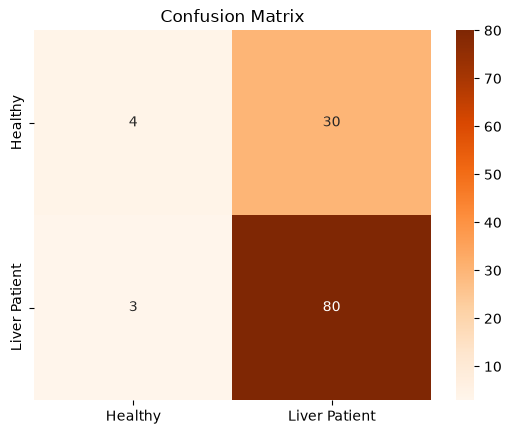

               precision    recall  f1-score   support

      Healthy       0.57      0.12      0.20        34
Liver Patient       0.73      0.96      0.83        83

     accuracy                           0.72       117
    macro avg       0.65      0.54      0.51       117
 weighted avg       0.68      0.72      0.64       117



In [8]:
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best = pipes[best_name]
print(f"Best: {best_name}")
y_pred  = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Healthy','Liver Patient'], yticklabels=['Healthy','Liver Patient'])
plt.title('Confusion Matrix'); plt.show()
print(classification_report(y_test, y_pred, target_names=['Healthy','Liver Patient']))

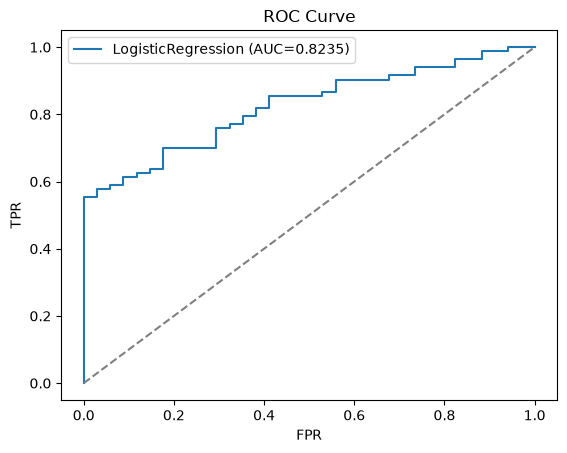

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{best_name} (AUC={results[best_name]["roc_auc"]})')
plt.plot([0,1],[0,1],'--',color='grey'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve'); plt.legend(); plt.show()

## 8 · Save

In [11]:
joblib.dump(best, '../models/liver_model.joblib')
metrics = {**results[best_name], 'model': best_name,
           'features': list(X.columns), 'test_size': 0.2, 'random_state': 42}
with open('../metrics/liver_metrics.json','w') as f: json.dump(metrics,f,indent=2)